In [15]:
source("../../Common/func.R")
library(dplyr)
library(readr)
library(ggplot2)

In [5]:
rawDF <- read_csv("../../../data/Electricity_B1E.csv", show_col_types = FALSE)
glimpse(rawDF)

Rows: 1,051,200
Columns: 12
$ unix_ts <dbl> 1333263600, 1333263660, 1333263720, 1333263780, 1333263840, 13…
$ V       <dbl> 117.8, 118.1, 118.1, 118.1, 117.7, 117.5, 117.6, 117.4, 117.6,…
$ I       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ f       <dbl> 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60, 60…
$ DPF     <dbl> 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.…
$ APF     <dbl> 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.…
$ P       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Pt      <dbl> 1755, 1755, 1755, 1755, 1755, 1755, 1755, 1755, 1755, 1755, 17…
$ Q       <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Qt      <dbl> 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 112, 11…
$ S       <dbl> 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,…
$ St      <dbl> 11329, 11330, 11330, 11330, 11330, 11330, 11330, 11330, 11331,…


In [6]:
B1E <- convert_timeStamp(rawDF, "unix_ts") %>%
    mutate(
        St_avg_rate = St - lag(St)
    )

In [7]:
(B1E_yearly_consumption <- yearly_consumption(B1E, "St_avg_rate"))

nDays,total_consumption,yearly_consumption_v1,yearly_consumption_v2
<int>,<dbl>,<dbl>,<dbl>
731,185.621,92.68354,92.8105


In [31]:
B1E_Jan_15 <- B1E %>%
    filter(month == "01", day <= "15") %>%
    group_by(hour) %>%
    summarise(
        cons_kWh = sum(St_avg_rate) / 1000
    )

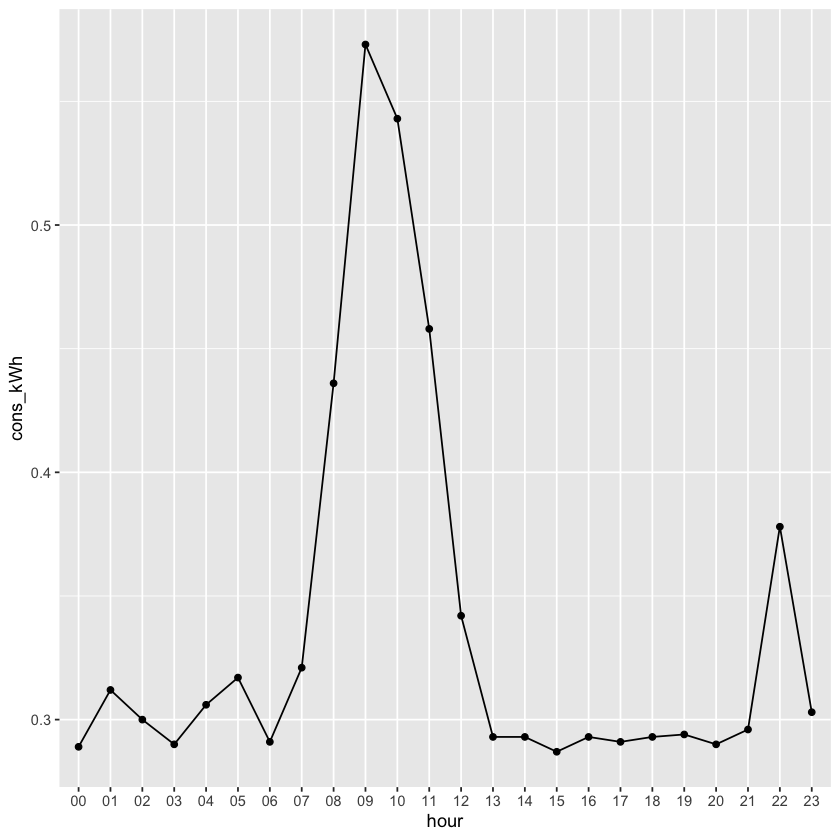

In [36]:
ggplot(B1E_Jan_15, aes(x = hour, y = cons_kWh, group = 1)) +
    geom_point() +
    geom_line()